# Image generation using Generative Adversarial Networks (GANS)

Using device: cuda


100%|██████████| 26.4M/26.4M [00:01<00:00, 17.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 305kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.63MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 29.0MB/s]


Starting Training...
Epoch [1/15] | Loss D: 1.0322 | Loss G: 1.3087
Epoch [2/15] | Loss D: 1.1466 | Loss G: 1.0507
Epoch [3/15] | Loss D: 1.2458 | Loss G: 1.1102
Epoch [4/15] | Loss D: 1.3298 | Loss G: 0.8397
Epoch [5/15] | Loss D: 1.2217 | Loss G: 0.9947
Epoch [6/15] | Loss D: 1.3281 | Loss G: 0.9853
Epoch [7/15] | Loss D: 1.2721 | Loss G: 0.8935
Epoch [8/15] | Loss D: 1.3858 | Loss G: 0.9696
Epoch [9/15] | Loss D: 1.3002 | Loss G: 0.9498
Epoch [10/15] | Loss D: 1.3441 | Loss G: 0.9735
Epoch [11/15] | Loss D: 1.2733 | Loss G: 0.9462
Epoch [12/15] | Loss D: 1.3341 | Loss G: 0.9852
Epoch [13/15] | Loss D: 1.3270 | Loss G: 0.8801
Epoch [14/15] | Loss D: 1.2955 | Loss G: 0.9432
Epoch [15/15] | Loss D: 1.4299 | Loss G: 0.9358
Training Complete!


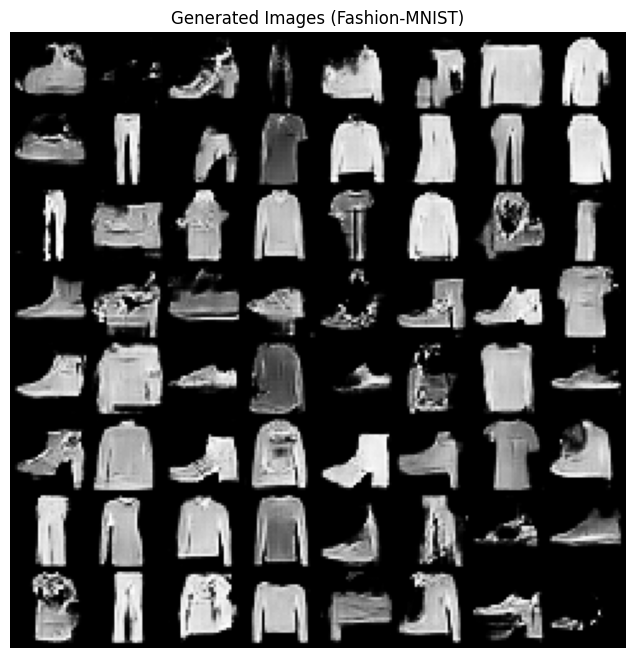

In [ ]:
# import libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torchvision.utils as vutils

# ---------------------------------------------------------
# 1. Hyperparameters & Device Setup
# ---------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

latent_dim = 100       # Size of latent vector z (input to generator)
lr_g = 0.0002          # Learning rate for Generator
lr_d = 0.0001          # Learning rate for Discriminator (TTUR for stability)
beta1 = 0.5            # Adam optimizer beta1
batch_size = 128
epochs = 15            # Fast training on Colab T4 GPU

# ---------------------------------------------------------
# 2. Data Preparation
# ---------------------------------------------------------
# Transform images to Tensor and normalize to range [-1, 1]
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

# ---------------------------------------------------------
# 3. Model Architectures
# ---------------------------------------------------------
class Generator(nn.Module):
    def __init__(self, z_dim):
        super(Generator, self).__init__()
        self.net = nn.Sequential(
            # Input: Latent vector z (z_dim x 1 x 1)
            nn.ConvTranspose2d(z_dim, 256, kernel_size=7, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            # State: 256 x 7 x 7

            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            # State: 128 x 14 x 14

            nn.ConvTranspose2d(128, 1, kernel_size=4, stride=2, padding=1, bias=False),
            nn.Tanh()
            # Output State: 1 x 28 x 28
        )

    def forward(self, x):
        x = x.view(x.size(0), x.size(1), 1, 1)
        return self.net(x)

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.net = nn.Sequential(
            # Input: Image (1 x 28 x 28)
            nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.25),
            # State: 64 x 14 x 14

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.25),
            # State: 128 x 7 x 7

            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 1),
            nn.Sigmoid()
            # Output: Scalar probability [0, 1]
        )

    def forward(self, x):
        return self.net(x)

# Weight initialization standard for DCGANs
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

netG = Generator(latent_dim).to(device)
netD = Discriminator().to(device)

netG.apply(weights_init)
netD.apply(weights_init)

# ---------------------------------------------------------
# 4. Loss & Optimizers
# ---------------------------------------------------------
criterion = nn.BCELoss()

# Optimizers using Adam with DCGAN recommended betas
optimizerG = optim.Adam(netG.parameters(), lr=lr_g, betas=(beta1, 0.999))
optimizerD = optim.Adam(netD.parameters(), lr=lr_d, betas=(beta1, 0.999))

# Fixed noise vector to inspect Generator progress visually
fixed_noise = torch.randn(64, latent_dim, device=device)

# ---------------------------------------------------------
# 5. Training Loop
# ---------------------------------------------------------
print("Starting Training...")

for epoch in range(epochs):
    for i, (real_images, _) in enumerate(dataloader):
        current_batch_size = real_images.size(0)
        real_images = real_images.to(device)

        # Label smoothing: 0.9 for real targets helps prevent Discriminator overconfidence
        labels_real = torch.full((current_batch_size, 1), 0.9, device=device)
        labels_fake = torch.full((current_batch_size, 1), 0.0, device=device)

        # -------------------------------------------------
        # (1) Train Discriminator: maximize log(D(x)) + log(1 - D(G(z)))
        # -------------------------------------------------
        netD.zero_grad()

        # Real Batch
        output_real = netD(real_images)
        loss_d_real = criterion(output_real, labels_real)

        # Fake Batch
        noise = torch.randn(current_batch_size, latent_dim, device=device)
        fake_images = netG(noise)
        output_fake = netD(fake_images.detach())
        loss_d_fake = criterion(output_fake, labels_fake)

        # Total Discriminator Loss
        loss_d = loss_d_real + loss_d_fake
        loss_d.backward()
        optimizerD.step()

        # -------------------------------------------------
        # (2) Train Generator: maximize log(D(G(z)))
        # -------------------------------------------------
        netG.zero_grad()

        # Generator wants Discriminator to label fake samples as real (using 1.0)
        labels_g_target = torch.full((current_batch_size, 1), 1.0, device=device)
        output_g = netD(fake_images)
        loss_g = criterion(output_g, labels_g_target)

        loss_g.backward()
        optimizerG.step()

    print(f"Epoch [{epoch+1}/{epochs}] | Loss D: {loss_d.item():.4f} | Loss G: {loss_g.item():.4f}")

print("Training Complete!")

# ---------------------------------------------------------
# 6. Generate & Visualize Final Results
# ---------------------------------------------------------
netG.eval()
with torch.no_grad():
    generated_imgs = netG(fixed_noise).detach().cpu()

# Plot 64 generated images as a 8x8 grid
grid = vutils.make_grid(generated_imgs, padding=2, normalize=True)

plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Generated Images (Fashion-MNIST)")
plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap='gray')
plt.show()

## TTUR (Two-Timescale Update Rule):

- The Discriminator uses a lower learning rate ($0.0001$) than the Generator ($0.0002$) to prevent the Discriminator from learning too fast and driving the Generator's gradients to zero.  

- One-Sided Label Smoothing: Real images use target labels of 0.9 instead of 1.0 to stabilize the Binary Cross-Entropy loss.  

- Transpose Convolutions: Upscaling is performed via ConvTranspose2d layers rather than fully-connected dense layers to retain spatial structure.